# Fourier Completo

Importando bibliotecas

In [1]:
import cv2
import numpy as np
from matplotlib import pyplot as plt
from math import sqrt,exp

Lendo imagem, e gerando as transformadas

In [2]:
img = cv2.imread('portinho.jpg',0)
fourier = np.fft.fft2(img)  # gerando a FFT
fourier1 =np.log(1+np.abs(fourier)) # Transformação de log para visualização da magnitude
phase=np.angle(fourier)  # Gerando a imagem da fase
center = np.fft.fftshift(fourier) # Gerando a magnitude no centro
inv_center = np.fft.ifftshift(center)
processed_img = np.fft.ifft2(inv_center)

(Text(0.5, 1.0, 'Fase'), ([], []), ([], []))

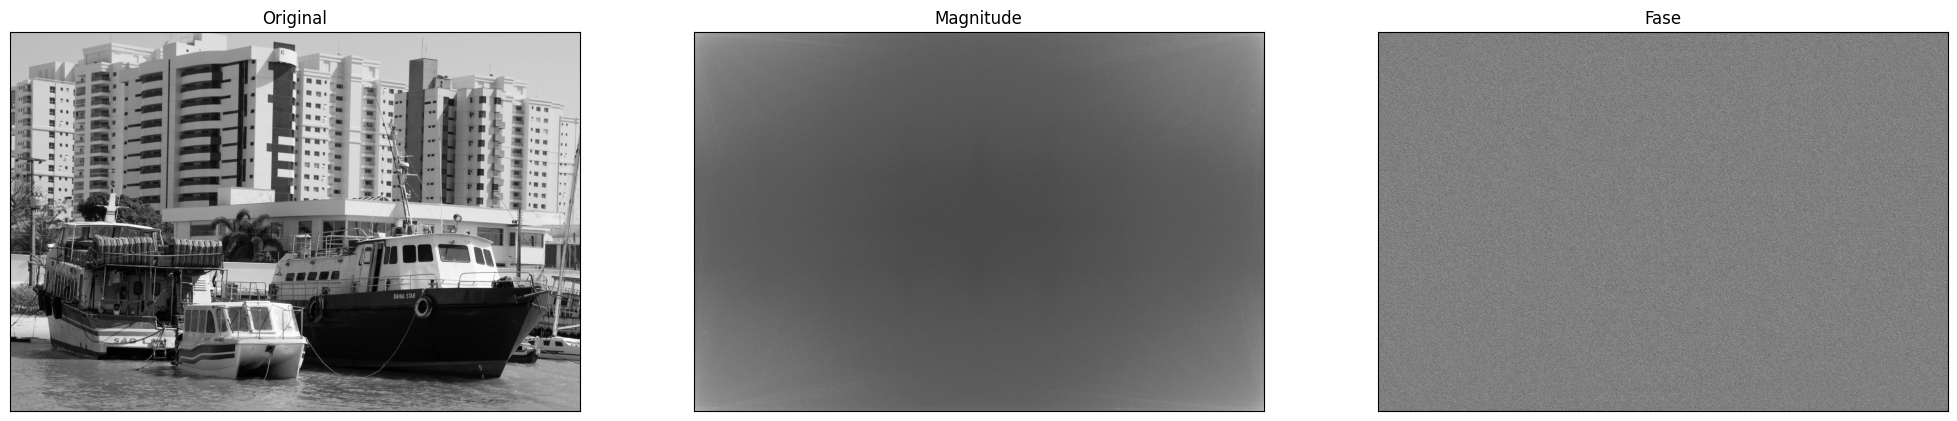

In [3]:
plt.figure(figsize=(25,20))
plt.subplot (1,3,1)
plt.imshow(img,cmap=plt.cm.gray)
plt.title('Original'),plt.xticks([]), plt.yticks([])
plt.subplot (1,3,2)
plt.imshow(fourier1,cmap=plt.cm.gray)
plt.title('Magnitude'),plt.xticks([]), plt.yticks([])
plt.subplot (1,3,3)
plt.imshow(phase,cmap=plt.cm.gray)
plt.title('Fase'),plt.xticks([]), plt.yticks([])

In [5]:
center = np.fft.fftshift(fourier)
center1=np.log(1+np.abs(center))

(Text(0.5, 1.0, 'Centralização'), ([], []), ([], []))

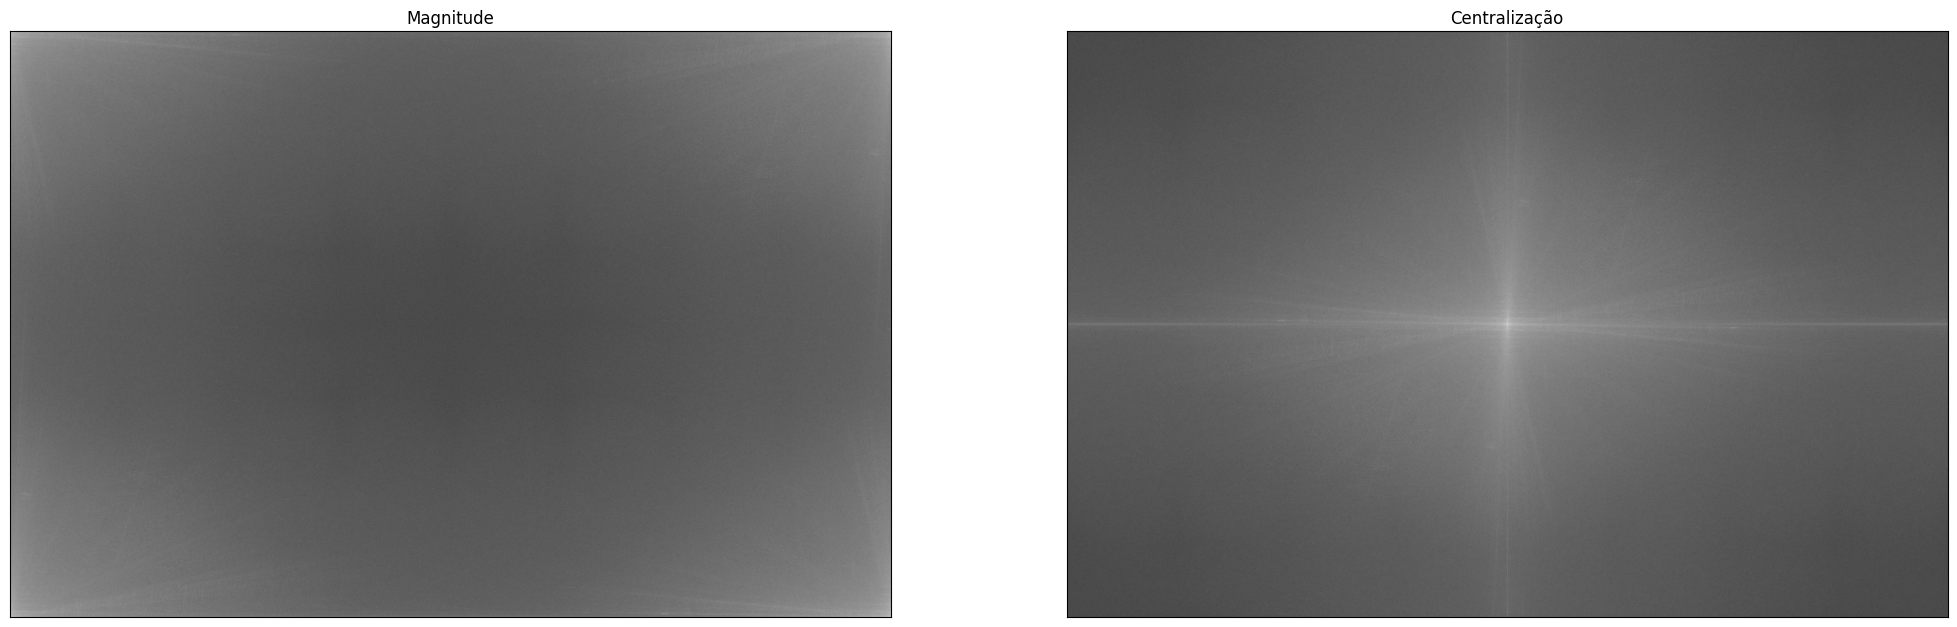

In [6]:
plt.figure(figsize=(25,20))
plt.subplot (1,2,1)
plt.imshow(fourier1,cmap=plt.cm.gray)
plt.title('Magnitude'),plt.xticks([]), plt.yticks([])
plt.subplot (1,2,2)
plt.imshow(center1,cmap=plt.cm.gray)
plt.title('Centralização'),plt.xticks([]), plt.yticks([])

Filtro passa baixa ideal

In [7]:
def distance(point1,point2):
    return sqrt((point1[0]-point2[0])**2 + (point1[1]-point2[1])**2)

def idealFilterLP(D0,imgShape):
    base = np.zeros(imgShape[:2])
    rows, cols = imgShape[:2]
    center = (rows/2,cols/2)
    for x in range(cols):
        for y in range(rows):
            if distance((y,x),center) < D0:
                base[y,x] = 1
    return base

In [8]:
img = cv2.imread('portinho.jpg',0)
original = np.fft.fft2(img)
center = np.fft.fftshift(original)

In [9]:
LowPassCenter = center * idealFilterLP(50,img.shape)

In [10]:
LowPass = idealFilterLP(50,img.shape)

(Text(0.5, 1.0, 'Espectro de Magnitude Filtrado'), ([], []), ([], []))

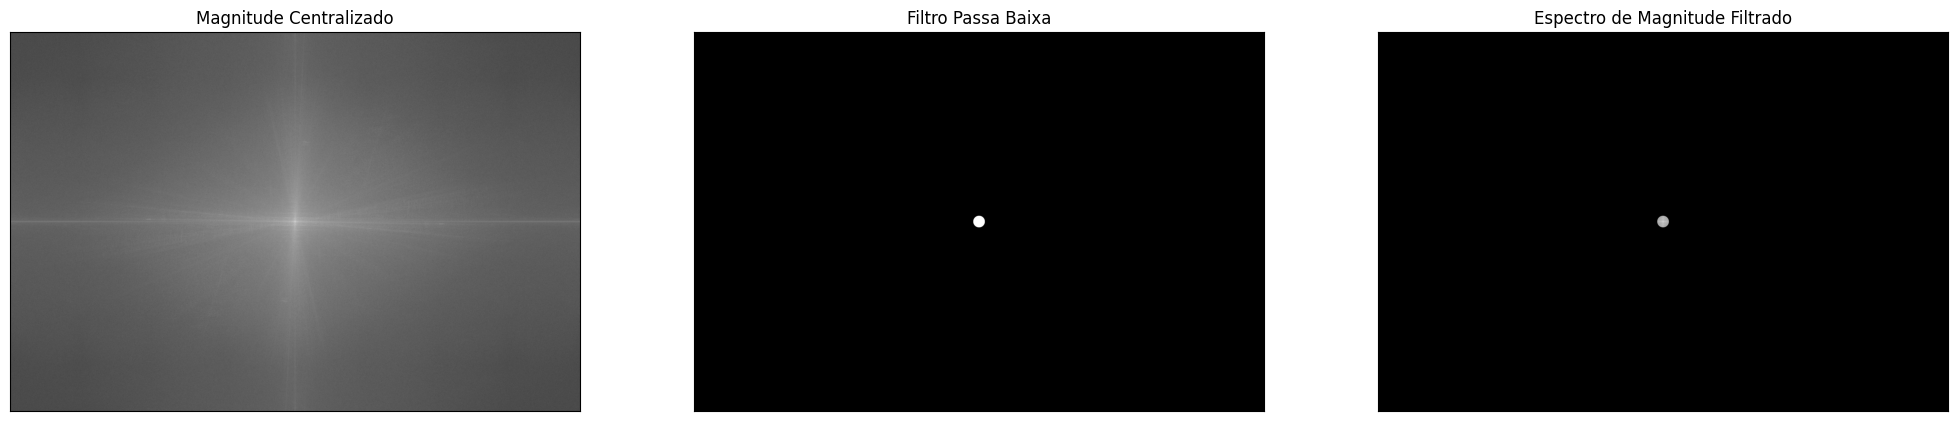

In [11]:
plt.figure(figsize=(25,20))
plt.subplot(131)
plt.imshow(np.log(1+np.abs(center)),cmap=plt.cm.gray )
plt.title("Magnitude Centralizado"),plt.xticks([]), plt.yticks([])
plt.subplot(132)
plt.imshow(np.abs(LowPass), cmap=plt.cm.gray)
plt.title("Filtro Passa Baixa"),plt.xticks([]), plt.yticks([])
plt.subplot(133)
plt.imshow(np.log(1+np.abs(LowPassCenter)),cmap=plt.cm.gray )
plt.title("Espectro de Magnitude Filtrado"),plt.xticks([]), plt.yticks([])

Volta do Espectro para os cantos

In [12]:
LowPass = np.fft.ifftshift(LowPassCenter)

(Text(0.5, 1.0, 'Decentralização'), ([], []), ([], []))

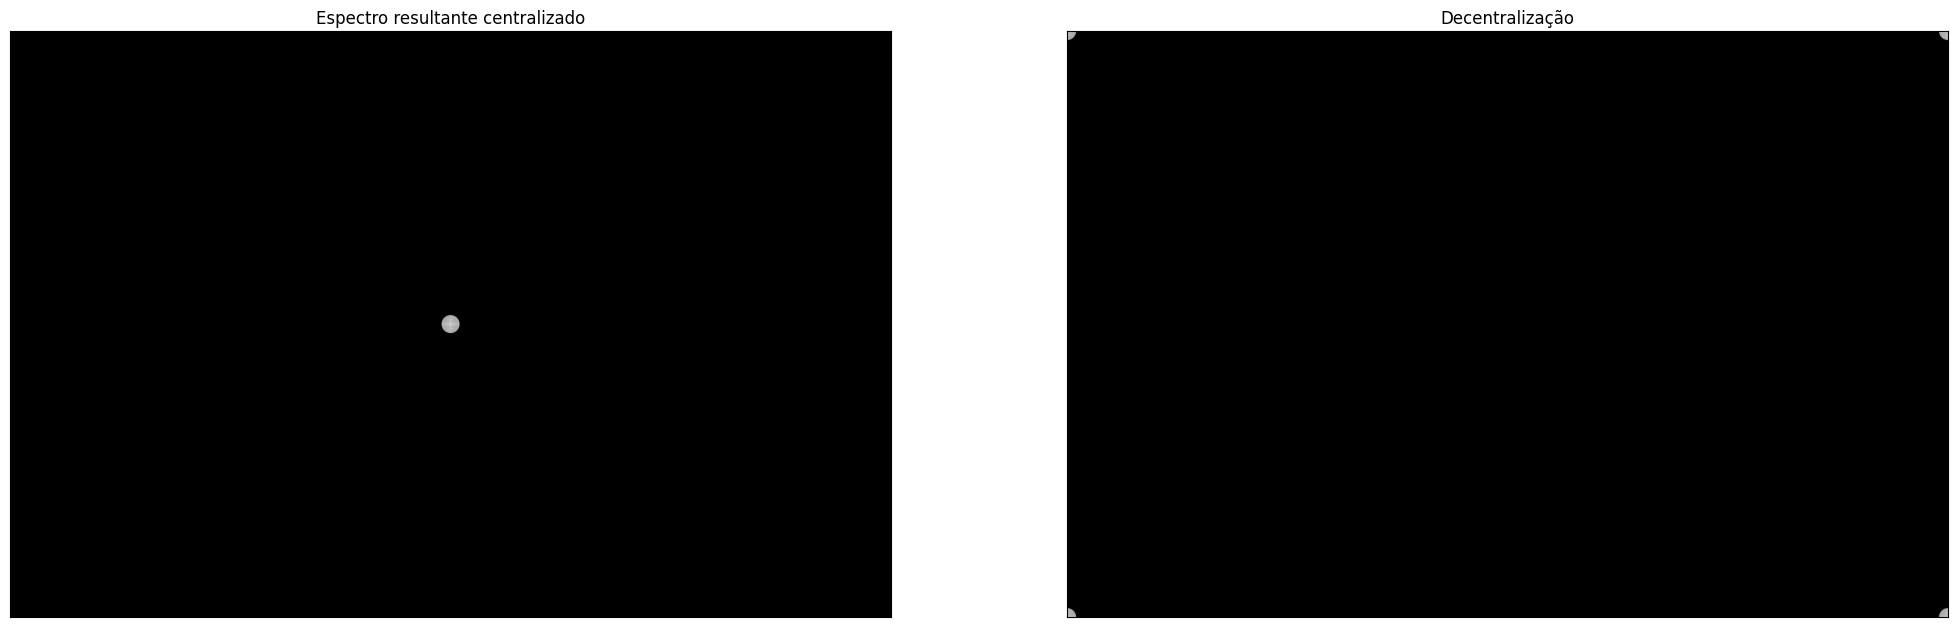

In [13]:
plt.figure(figsize=(25,20))
plt.subplot(121)
plt.imshow(np.log(1+np.abs(LowPassCenter)),cmap=plt.cm.gray )
plt.title("Espectro resultante centralizado"),plt.xticks([]), plt.yticks([])
plt.subplot(122)
plt.imshow(np.log(1+np.abs(LowPass)), cmap=plt.cm.gray)
plt.title("Decentralização"),plt.xticks([]), plt.yticks([])

Visualizando o resultado final

In [14]:
inverse_LowPass = np.fft.ifft2(LowPass)

(Text(0.5, 1.0, 'Filtrada'), ([], []), ([], []))

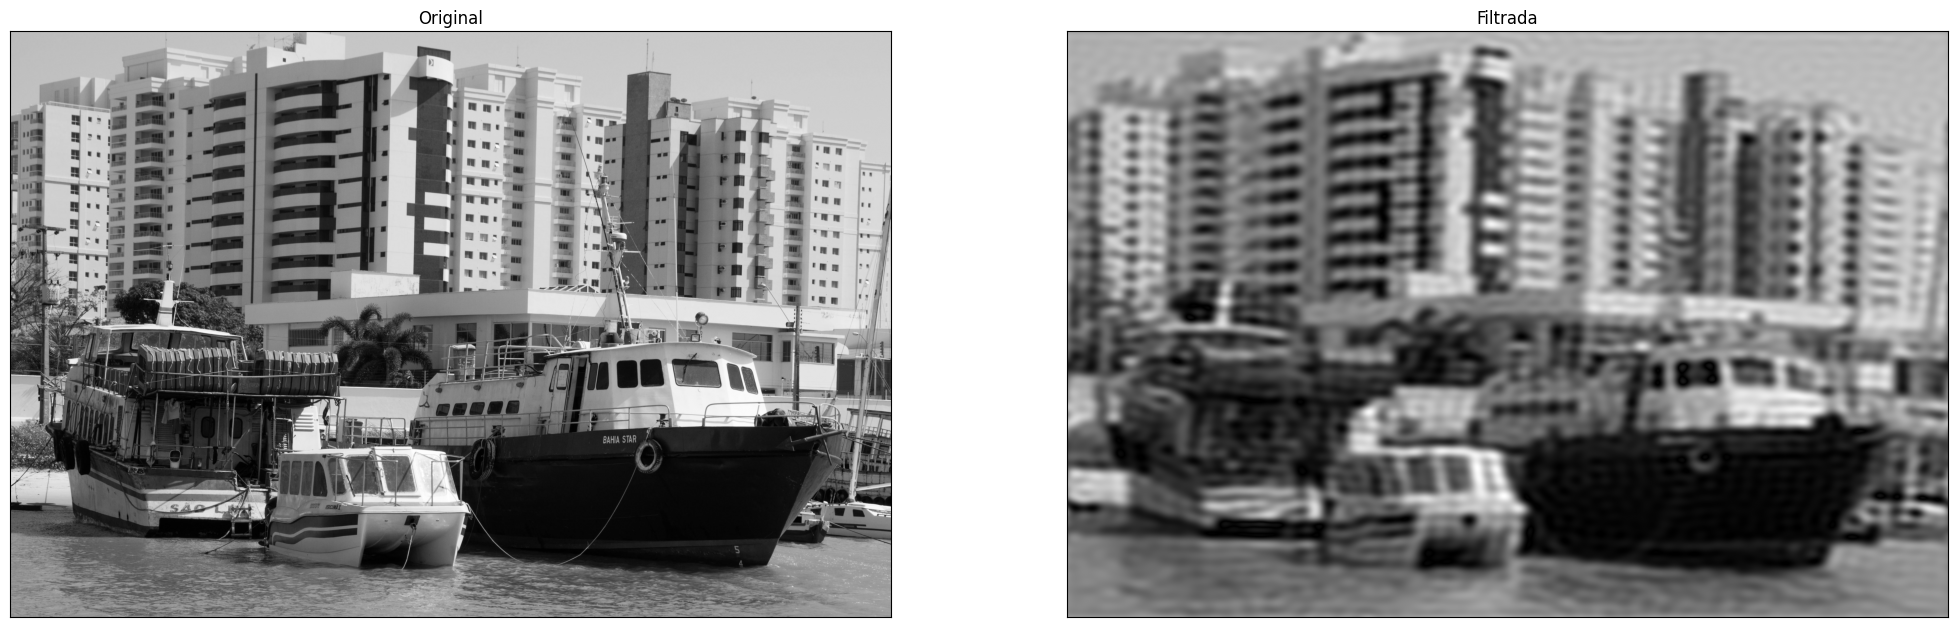

In [15]:
plt.figure(figsize=(25,20))
plt.subplot (1,2,1)
plt.imshow(img,cmap=plt.cm.gray)
plt.title('Original'),plt.xticks([]), plt.yticks([])
plt.subplot (1,2,2)
plt.imshow(np.abs(inverse_LowPass),cmap=plt.cm.gray)
plt.title('Filtrada'),plt.xticks([]), plt.yticks([])